# RQ2: Temporal Impact of Peak-Hour Congestion on WAV Demand

**Research Question:** How does the temporal impact of peak-hour congestion on WAV total
demand volume differ between High-Density Commercial Zones (Manhattan) and Low-Density
Residential Zones (Staten Island)?

**Hypothesis:** Higher abandonment rates during traffic spikes are caused by the availability
of alternative transportation modes (e.g., subways) in densely populated areas like Manhattan.
In contrast, users in residential areas like Staten Island, where transit alternatives are
limited, are forced to wait — leading to continuous demand despite congestion.

---
**Notebook Structure:**
1. Setup & Data Loading
2. Filtering & Borough Split
3. Feature Engineering
4. Hourly Aggregation
5. EDA
6. Seasonal Decomposition
7. Stationarity Testing (ADF + KPSS)
8. Baseline Models
9. SARIMAX Model
10. Evaluation & Comparison
11. Interpretation & Results

## 1. Setup & Data Loading

We mount Google Drive to access the NYC TLC HVFHV dataset (January–February 2024)
and install required libraries for time series analysis.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%pip install statsforecast pmdarima -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import statsmodels.api as sm

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from scipy.stats import skew
from pylab import rcParams

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
rcParams['figure.figsize'] = 12, 6

print('All imports successful.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 6.4 MB/s eta 0:00:00
All imports successful.


In [ ]:
DATA_PATH = '/content/drive/MyDrive/CISC351 Group Assignment Q2-Time_Series Data /'

COLS_NEEDED = [
    'pickup_datetime', 'PULocationID', 'wav_request_flag',
    'trip_miles', 'trip_time', 'tolls', 'sales_tax',
    'congestion_surcharge', 'shared_request_flag'
]

# Get borough IDs first
zone_lookup = pd.read_csv(DATA_PATH + 'taxi_zone_lookup.csv').dropna()
zone_lookup = zone_lookup.rename(columns={'LocationID': 'PULocationID'})

manhattan_IDs    = zone_lookup[zone_lookup['Borough'] == 'Manhattan']['PULocationID'].unique().tolist()
statenisland_IDs = zone_lookup[zone_lookup['Borough'] == 'Staten Island']['PULocationID'].unique().tolist()
target_IDs = manhattan_IDs + statenisland_IDs

# Load parquet files but immediately filter to target boroughs only
jan = pd.read_parquet(DATA_PATH + 'fhvhv_tripdata_2024-01.parquet', columns=COLS_NEEDED)
jan = jan[jan['PULocationID'].isin(target_IDs) & (jan['shared_request_flag'] == 'N')]

feb = pd.read_parquet(DATA_PATH + 'fhvhv_tripdata_2024-02.parquet', columns=COLS_NEEDED)
feb = feb[feb['PULocationID'].isin(target_IDs) & (feb['shared_request_flag'] == 'N')]

combined_df = pd.concat([jan, feb], axis=0, ignore_index=True)
del jan, feb

print(f'Combined shape: {combined_df.shape}')
print(combined_df['wav_request_flag'].value_counts())

Combined shape: (15621020, 9)
wav_request_flag
N    15586529
Y       34491
Name: count, dtype: int64


## 2. Filtering & Borough Split

We filter the combined dataset to only include pickups from **Manhattan** (high-density)
and **Staten Island** (low-density), which serve as our treatment and control groups
respectively.

Shared rides are excluded to ensure trip times reflect individual trips only.
The data is then split into two separate DataFrames for parallel analysis.

In [ ]:
# Get location IDs for each borough
manhattan_IDs    = zone_lookup[zone_lookup['Borough'] == 'Manhattan']['PULocationID'].unique().tolist()
statenisland_IDs = zone_lookup[zone_lookup['Borough'] == 'Staten Island']['PULocationID'].unique().tolist()

# Filter to only Manhattan and Staten Island pickups
combined_df = combined_df[combined_df['PULocationID'].isin(manhattan_IDs + statenisland_IDs)].copy()

# Merge borough name in
combined_df = combined_df.merge(zone_lookup[['PULocationID', 'Borough']], on='PULocationID', how='inner')

# Exclude shared rides
combined_df = combined_df[combined_df['shared_request_flag'] == 'N'].copy()
combined_df.reset_index(drop=True, inplace=True)

# Split into two borough DataFrames
manhattan_df    = combined_df[combined_df['Borough'] == 'Manhattan'].copy()
statenisland_df = combined_df[combined_df['Borough'] == 'Staten Island'].copy()

print(f'Manhattan rows:     {len(manhattan_df):,}')
print(f'Staten Island rows: {len(statenisland_df):,}')
print()
print('WAV Request breakdown - Manhattan:')
print(manhattan_df['wav_request_flag'].value_counts())
print()
print('WAV Request breakdown - Staten Island:')
print(statenisland_df['wav_request_flag'].value_counts())

Manhattan rows:     15,089,373
Staten Island rows: 531,647

WAV Request breakdown - Manhattan:
wav_request_flag
N    15056363
Y       33010
Name: count, dtype: int64

WAV Request breakdown - Staten Island:
wav_request_flag
N    530166
Y      1481
Name: count, dtype: int64


## 3. Feature Engineering

We engineer temporal and exogenous features before aggregating to hourly intervals.

Key features created:
- `total_demand`: binary flag (1 = WAV requested, 0 = not)
- `is_weekend`: whether the trip occurred on a Saturday or Sunday
- `is_peak_hour`: whether the trip occurred between 7am–7pm (covers medical appointments and office hours)
- `is_peak_weekday` / `is_peak_weekend`: interaction terms to be used as exogenous variables in SARIMAX

In [ ]:
def engineer_features(df):
    df = df.copy()
    # Binary target: WAV requested
    df['total_demand'] = df['wav_request_flag'].map({'Y': 1, 'N': 0})
    # Temporal features
    df['weekday']      = df['pickup_datetime'].dt.weekday  # 0=Mon, 6=Sun
    df['hour']         = df['pickup_datetime'].dt.hour
    df['is_weekend']   = (df['weekday'] >= 5).astype(int)
    # Peak hour: 7am-7pm
    df['is_peak_hour']    = df['hour'].isin(range(7, 20)).astype(int)
    # Interaction terms for SARIMAX
    df['is_peak_weekday'] = df['is_peak_hour'] * (1 - df['is_weekend'])
    df['is_peak_weekend'] = df['is_peak_hour'] * df['is_weekend']
    return df

manhattan_df    = engineer_features(manhattan_df)
statenisland_df = engineer_features(statenisland_df)

print('Feature engineering complete.')
print(manhattan_df[['pickup_datetime','total_demand','weekday',
                     'is_weekend','is_peak_hour','is_peak_weekday',
                     'is_peak_weekend']].head(3))

Feature engineering complete.
      pickup_datetime  total_demand  weekday  is_weekend  is_peak_hour  \
0 2024-01-01 00:28:08             0        0           0             0   
1 2024-01-01 00:12:53             0        0           0             0   
2 2024-01-01 00:23:05             0        0           0             0   

   is_peak_weekday  is_peak_weekend  
0                0                0  
1                0                0  
2                0                0  


## 4. Hourly Aggregation

We aggregate individual trips into hourly intervals. `total_demand` becomes the
count of WAV requests per hour, creating a continuous time series suitable for
SARIMAX modelling.

Lagged exogenous variables are created **after** aggregation to prevent look-ahead
bias — since we cannot know the total tolls or congestion surcharge for an hour until
that hour ends, we use the previous hour's value (t-1) as the predictor.

In [ ]:
def aggregate_hourly(df):
    df = df.set_index('pickup_datetime').sort_index()

    hourly = df.resample('H').agg(
        total_demand         = ('total_demand',         'sum'),
        is_peak_weekday      = ('is_peak_weekday',      'max'),
        is_peak_weekend      = ('is_peak_weekend',      'max'),
        is_peak_hour         = ('is_peak_hour',         'max'),
        is_weekend           = ('is_weekend',           'max'),
        trip_miles           = ('trip_miles',           'mean'),
        trip_time            = ('trip_time',            'mean'),
        tolls                = ('tolls',                'sum'),
        congestion_surcharge = ('congestion_surcharge', 'sum'),
    ).fillna(0)

    # Create lagged variables AFTER aggregation
    hourly['lagged_tolls']                = hourly['tolls'].shift(1)
    hourly['lagged_congestion_surcharge'] = hourly['congestion_surcharge'].shift(1)
    hourly['lagged_trip_time']            = hourly['trip_time'].shift(1)

    hourly = hourly.fillna(0).reset_index()
    return hourly

m_hourly = aggregate_hourly(manhattan_df)
s_hourly = aggregate_hourly(statenisland_df)

print(f'Manhattan hourly points:     {len(m_hourly)}')
print(f'Staten Island hourly points: {len(s_hourly)}')
print()
print(m_hourly[['pickup_datetime', 'total_demand', 'is_peak_hour',
                 'lagged_trip_time']].head(5))

Manhattan hourly points:     1440
Staten Island hourly points: 1440

      pickup_datetime  total_demand  is_peak_hour  lagged_trip_time
0 2024-01-01 00:00:00            12             0          0.000000
1 2024-01-01 01:00:00            34             0       1288.569571
2 2024-01-01 02:00:00            26             0       1313.591231
3 2024-01-01 03:00:00            20             0       1226.446378
4 2024-01-01 04:00:00             7             0       1186.446455


## 5. Exploratory Data Analysis (EDA)

Before modelling, we visualize WAV demand patterns to understand the structure
of our time series. We examine:
- The overall time series for both boroughs
- Average demand by hour of day (daily seasonality)
- Average demand by day of week (weekly seasonality)

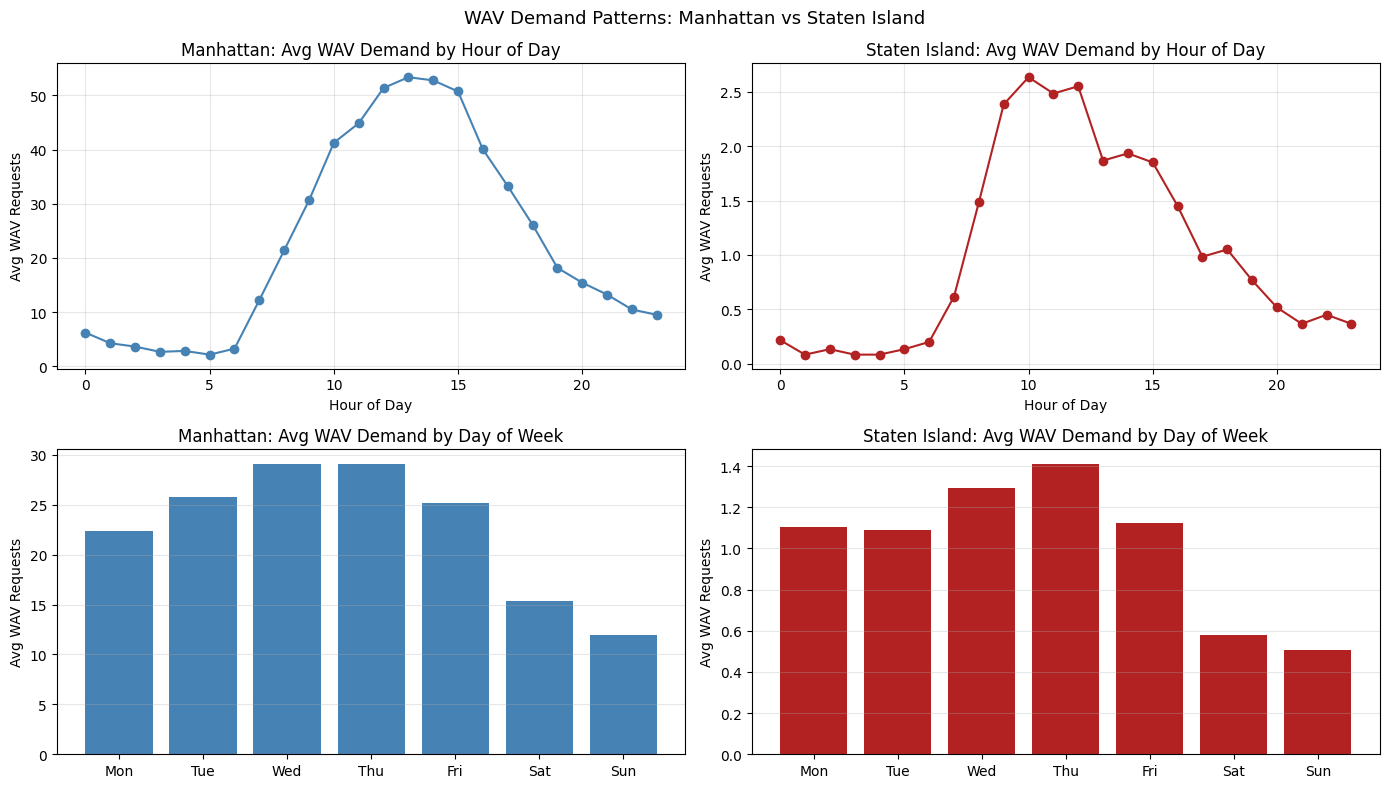

In [ ]:
m_hourly['hour_of_day'] = m_hourly['pickup_datetime'].dt.hour
s_hourly['hour_of_day'] = s_hourly['pickup_datetime'].dt.hour
m_hourly['weekday']     = m_hourly['pickup_datetime'].dt.weekday
s_hourly['weekday']     = s_hourly['pickup_datetime'].dt.weekday

days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# By hour of day
m_hourly.groupby('hour_of_day')['total_demand'].mean().plot(
    ax=axes[0][0], color='steelblue', marker='o')
axes[0][0].set_title('Manhattan: Avg WAV Demand by Hour of Day')
axes[0][0].set_xlabel('Hour of Day')
axes[0][0].set_ylabel('Avg WAV Requests')
axes[0][0].grid(True, alpha=0.3)

s_hourly.groupby('hour_of_day')['total_demand'].mean().plot(
    ax=axes[0][1], color='firebrick', marker='o')
axes[0][1].set_title('Staten Island: Avg WAV Demand by Hour of Day')
axes[0][1].set_xlabel('Hour of Day')
axes[0][1].set_ylabel('Avg WAV Requests')
axes[0][1].grid(True, alpha=0.3)

# By day of week
m_by_day = m_hourly.groupby('weekday')['total_demand'].mean()
axes[1][0].bar(range(7), m_by_day.values, color='steelblue')
axes[1][0].set_xticks(range(7))
axes[1][0].set_xticklabels(days)
axes[1][0].set_title('Manhattan: Avg WAV Demand by Day of Week')
axes[1][0].set_ylabel('Avg WAV Requests')
axes[1][0].grid(True, alpha=0.3, axis='y')

s_by_day = s_hourly.groupby('weekday')['total_demand'].mean()
axes[1][1].bar(range(7), s_by_day.values, color='firebrick')
axes[1][1].set_xticks(range(7))
axes[1][1].set_xticklabels(days)
axes[1][1].set_title('Staten Island: Avg WAV Demand by Day of Week')
axes[1][1].set_ylabel('Avg WAV Requests')
axes[1][1].grid(True, alpha=0.3, axis='y')

plt.suptitle('WAV Demand Patterns: Manhattan vs Staten Island', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Seasonal Decomposition

We decompose the hourly time series into three components:
- **Trend**: long-term directional shifts in WAV demand
- **Seasonality**: repeating cycles (daily and weekly patterns)
- **Residuals**: remaining noise after trend and seasonality are removed

We use a **multiplicative** model since seasonal fluctuations scale proportionally
with the overall demand level. A sqrt transformation is applied first to reduce
the extreme right skew (skewness = 21.6) observed in raw demand.

Skewness before sqrt - Manhattan:    1.063
Skewness after sqrt  - Manhattan:    0.345

Skewness before sqrt - Staten Island: 1.569
Skewness after sqrt  - Staten Island: 0.564


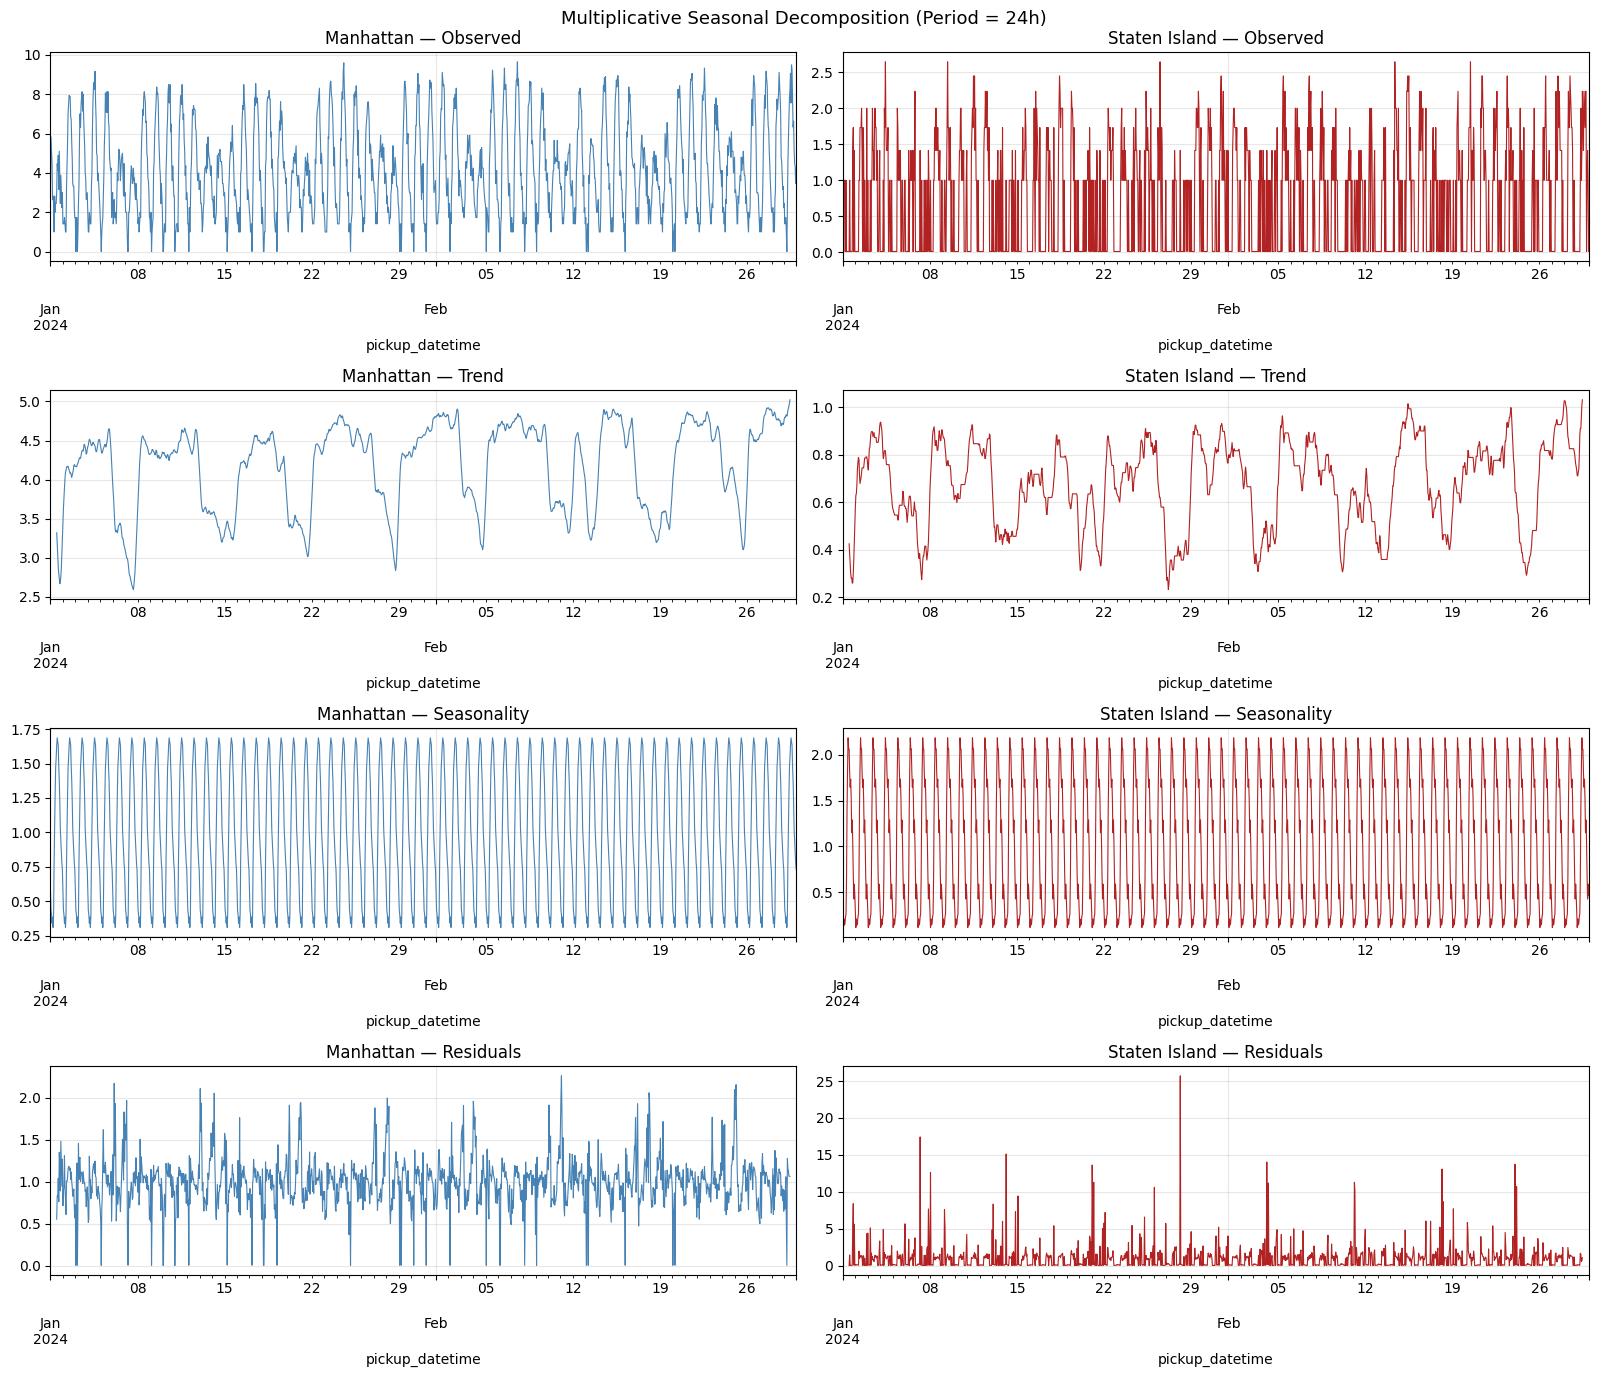

In [ ]:
# Apply sqrt transformation to reduce skew
m_hourly['sqrt_total_demand'] = np.sqrt(m_hourly['total_demand'])
s_hourly['sqrt_total_demand'] = np.sqrt(s_hourly['total_demand'])

print(f'Skewness before sqrt - Manhattan:    {skew(m_hourly["total_demand"]):.3f}')
print(f'Skewness after sqrt  - Manhattan:    {skew(m_hourly["sqrt_total_demand"]):.3f}')
print()
print(f'Skewness before sqrt - Staten Island: {skew(s_hourly["total_demand"]):.3f}')
print(f'Skewness after sqrt  - Staten Island: {skew(s_hourly["sqrt_total_demand"]):.3f}')

# Set datetime index for decomposition
m_ts = m_hourly.set_index('pickup_datetime')['sqrt_total_demand']
s_ts = s_hourly.set_index('pickup_datetime')['sqrt_total_demand']

# Replace zeros to avoid division errors in multiplicative model
m_ts = m_ts.replace(0, 0.01)
s_ts = s_ts.replace(0, 0.01)

# Decompose with period=24 (daily cycle)
m_decomp = seasonal_decompose(m_ts, model='multiplicative', period=24)
s_decomp = seasonal_decompose(s_ts, model='multiplicative', period=24)

components = ['observed', 'trend', 'seasonal', 'resid']
labels     = ['Observed', 'Trend', 'Seasonality', 'Residuals']

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for i, (comp, label) in enumerate(zip(components, labels)):
    getattr(m_decomp, comp).plot(ax=axes[i][0], color='steelblue', linewidth=0.8)
    axes[i][0].set_title(f'Manhattan — {label}')
    axes[i][0].grid(True, alpha=0.3)

    getattr(s_decomp, comp).plot(ax=axes[i][1], color='firebrick', linewidth=0.8)
    axes[i][1].set_title(f'Staten Island — {label}')
    axes[i][1].grid(True, alpha=0.3)

plt.suptitle('Multiplicative Seasonal Decomposition (Period = 24h)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Stationarity Testing (ADF + KPSS)

SARIMAX requires a stationary time series, one where the mean, variance, and
autocorrelation structure remain constant over time.

We use two complementary tests to avoid false positives from either test alone:
- **ADF Test** — H₀: series is non-stationary. Reject if p < 0.05 → stationary ✓
- **KPSS Test** — H₀: series is stationary. Fail to reject if p > 0.05 → stationary ✓

If both tests agree the series is stationary, no differencing is needed (d=0).
If not, we apply first-order differencing (.diff()) and retest.

In [ ]:
def run_stationarity_tests(series, name):
    print(f'{"="*55}')
    print(f'Stationarity Tests: {name}')
    print(f'{"="*55}')

    # ADF Test
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna(), autolag='AIC')
    adf_stationary = adf_p < 0.05
    print(f'\nADF Test:')
    print(f'  Statistic : {adf_stat:.4f}')
    print(f'  p-value   : {adf_p:.6f}')
    print(f'  Result    : {"✓ STATIONARY" if adf_stationary else "✗ NON-STATIONARY"}')

    # KPSS Test
    kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')
    kpss_stationary = kpss_p > 0.05
    print(f'\nKPSS Test:')
    print(f'  Statistic : {kpss_stat:.4f}')
    print(f'  p-value   : {kpss_p:.6f}')
    print(f'  Result    : {"✓ STATIONARY" if kpss_stationary else "✗ NON-STATIONARY"}')

    both_stationary = adf_stationary and kpss_stationary
    print(f'\nVerdict: {"✓ STATIONARY — ready for SARIMAX" if both_stationary else "✗ NOT STATIONARY — apply differencing"}')
    print()
    return both_stationary

m_stationary = run_stationarity_tests(m_ts, 'Manhattan (sqrt demand)')
s_stationary = run_stationarity_tests(s_ts, 'Staten Island (sqrt demand)')

if not m_stationary:
    print('Applying differencing to Manhattan...')
    run_stationarity_tests(m_ts.diff().dropna(), 'Manhattan (1st-order diff)')
else:
    print('Manhattan: no differencing needed.')

if not s_stationary:
    print('Applying differencing to Staten Island...')
    run_stationarity_tests(s_ts.diff().dropna(), 'Staten Island (1st-order diff)')
else:
    print('Staten Island: no differencing needed.')

Stationarity Tests: Manhattan (sqrt demand)

ADF Test:
  Statistic : -4.9367
  p-value   : 0.000030
  Result    : ✓ STATIONARY

KPSS Test:
  Statistic : 0.4008
  p-value   : 0.076824
  Result    : ✓ STATIONARY

Verdict: ✓ STATIONARY — ready for SARIMAX

Stationarity Tests: Staten Island (sqrt demand)

ADF Test:
  Statistic : -4.8021
  p-value   : 0.000054
  Result    : ✓ STATIONARY

KPSS Test:
  Statistic : 0.1774
  p-value   : 0.100000
  Result    : ✓ STATIONARY

Verdict: ✓ STATIONARY — ready for SARIMAX

Manhattan: no differencing needed.
Staten Island: no differencing needed.


## 8. Baseline Models

Before fitting SARIMAX, we establish baseline models to benchmark against.
A good model should meaningfully outperform these simple baselines.

We test three baselines on the **last 2 weeks (336 hours)** as the test set:
- **Naive**: predicts next value = last observed value
- **Seasonal Naive (24h)**: predicts next value = value from same hour yesterday
- **Moving Average (24h)**: predicts next value = rolling 24-hour average

All baselines are evaluated using **RMSE** (Root Mean Squared Error).

In [ ]:
# Temporal train/test split — last 336 hours (2 weeks) as test
TEST_HOURS = 336

m_train = m_hourly.iloc[:-TEST_HOURS].copy()
m_test  = m_hourly.iloc[-TEST_HOURS:].copy()
s_train = s_hourly.iloc[:-TEST_HOURS].copy()
s_test  = s_hourly.iloc[-TEST_HOURS:].copy()

print(f'Manhattan  — Train: {len(m_train)} hrs | Test: {len(m_test)} hrs')
print(f'Staten Island — Train: {len(s_train)} hrs | Test: {len(s_test)} hrs')

def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def evaluate_baselines(train, test, borough_name):
    actual = test['total_demand'].values
    n      = len(actual)
    full   = pd.concat([train, test])['total_demand'].values
    train_len = len(train)
    results = {}

    # Naive
    naive_pred = np.full(n, train['total_demand'].iloc[-1])
    results['Naive'] = rmse(actual, naive_pred)

    # Seasonal Naive (24h)
    seasonal_pred = np.array([full[train_len + i - 24] for i in range(n)])
    results['Seasonal Naive (24h)'] = rmse(actual, seasonal_pred)

    # Moving Average (24h)
    ma_val = train['total_demand'].rolling(window=24).mean().iloc[-1]
    results['Moving Average (24h)'] = rmse(actual, np.full(n, ma_val))

    print(f'\nBaseline RMSE — {borough_name}:')
    for model, score in results.items():
        print(f'  {model:<25}: {score:.4f}')

    return results

m_baseline = evaluate_baselines(m_train, m_test, 'Manhattan')
s_baseline = evaluate_baselines(s_train, s_test, 'Staten Island')

Manhattan  — Train: 1104 hrs | Test: 336 hrs
Staten Island — Train: 1104 hrs | Test: 336 hrs

Baseline RMSE — Manhattan:
  Naive                    : 26.3588
  Seasonal Naive (24h)     : 13.2524
  Moving Average (24h)     : 23.6625

Baseline RMSE — Staten Island:
  Naive                    : 1.9556
  Seasonal Naive (24h)     : 1.5343
  Moving Average (24h)     : 1.6573


## 9. SARIMAX Model

We fit a SARIMAX(1,0,1)(1,0,1)[24] model to each borough separately.

**Order selection:**
- (p=1, d=0, q=1): AR(1) + MA(1), no differencing needed (confirmed by ADF/KPSS)
- (P=1, D=0, Q=1)[s=24]: seasonal AR and MA terms capturing the 24-hour daily cycle
- d=0 and D=0: both series confirmed stationary, no differencing required

**Exogenous variables:**
- `is_peak_weekday`: peak hour on a weekday (corporate/medical demand)
- `is_peak_weekend`: peak hour on a weekend (leisure demand)
- `lagged_trip_time`: previous hour's avg trip time as a proxy for congestion

We compare the seasonal coefficients between boroughs to assess how
congestion affects WAV demand differently in high vs low density areas.

In [ ]:
EXOG_COLS = ['is_peak_weekday', 'is_peak_weekend', 'lagged_trip_time']
TARGET    = 'sqrt_total_demand'

def fit_sarimax(train, test, borough_name,
                order=(1,0,1), seasonal_order=(1,0,1,24)):
    print(f'Fitting SARIMAX{order}x{seasonal_order} — {borough_name}...')

    train_y    = train.set_index('pickup_datetime')[TARGET]
    test_y     = test.set_index('pickup_datetime')[TARGET]
    train_exog = train.set_index('pickup_datetime')[EXOG_COLS]
    test_exog  = test.set_index('pickup_datetime')[EXOG_COLS]

    model = SARIMAX(
        train_y,
        exog           = train_exog,
        order          = order,
        seasonal_order = seasonal_order,
        enforce_stationarity  = False,
        enforce_invertibility = False
    )
    result = model.fit(disp=False)

    # Forecast on test set
    forecast = result.forecast(steps=len(test), exog=test_exog)

    # Convert back from sqrt scale to original for RMSE
    actual_orig   = test['total_demand'].values
    forecast_orig = np.maximum(forecast.values ** 2, 0)

    sarimax_rmse = rmse(actual_orig, forecast_orig)
    print(f'  AIC  : {result.aic:.2f}')
    print(f'  BIC  : {result.bic:.2f}')
    print(f'  RMSE : {sarimax_rmse:.4f}')
    print()

    return result, forecast, sarimax_rmse

m_result, m_forecast, m_sarimax_rmse = fit_sarimax(m_train, m_test, 'Manhattan')
s_result, s_forecast, s_sarimax_rmse = fit_sarimax(s_train, s_test, 'Staten Island')

Fitting SARIMAX(1, 0, 1)x(1, 0, 1, 24) — Manhattan...
  AIC  : 2282.03
  BIC  : 2321.89
  RMSE : 8.2001

Fitting SARIMAX(1, 0, 1)x(1, 0, 1, 24) — Staten Island...
  AIC  : 1846.16
  BIC  : 1886.02
  RMSE : 1.3306



## 10. Evaluation & Comparison

We compare SARIMAX against all three baselines using RMSE, then visualize
the forecast against actual demand for both boroughs.

MODEL COMPARISON — RMSE (original WAV demand scale)
Model                           Manhattan  Staten Island
----------------------------------------------------------
Naive                             26.3588         1.9556
Seasonal Naive (24h)              13.2524         1.5343
Moving Average (24h)              23.6625         1.6573
SARIMAX(1,0,1)(1,0,1)[24]          8.2001         1.3306


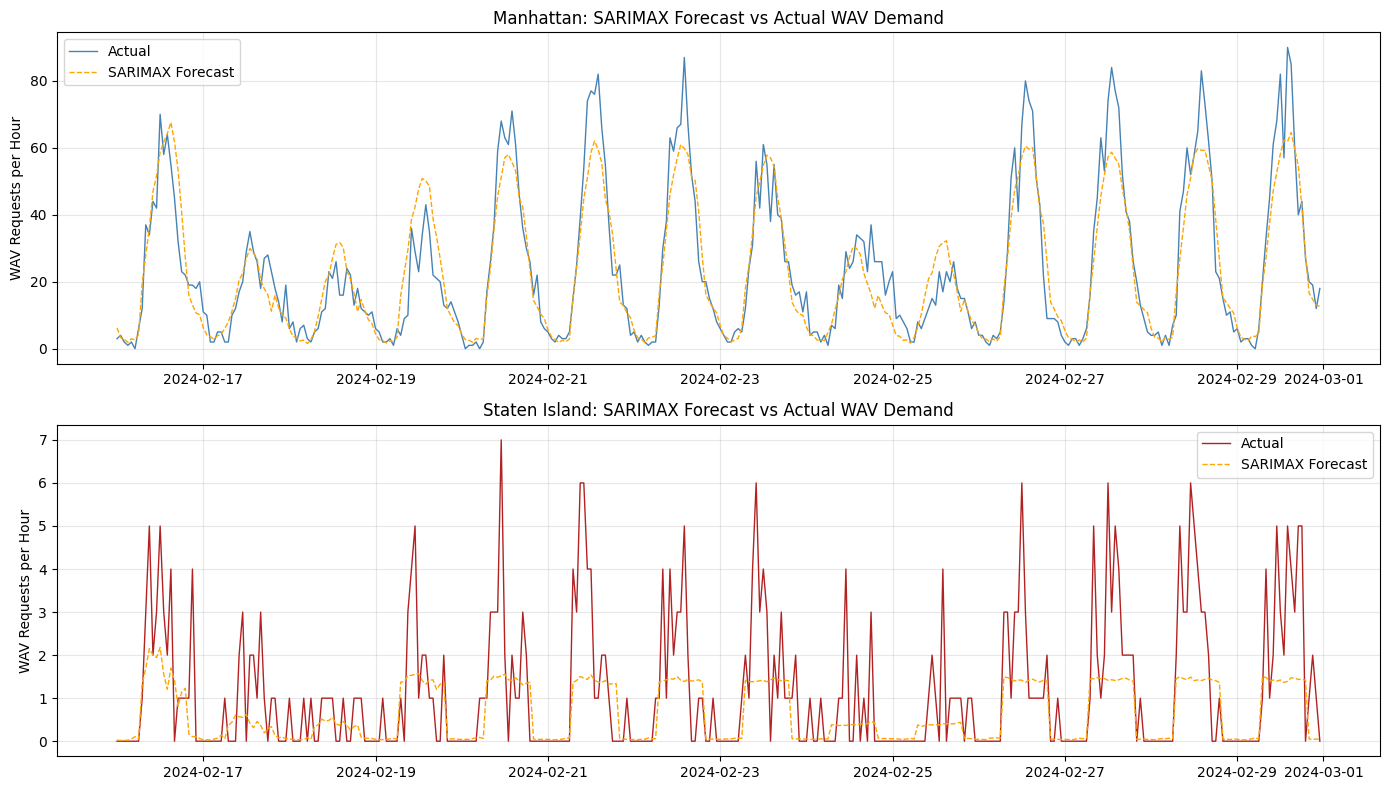

In [ ]:
# RMSE Summary Table
print('=' * 58)
print('MODEL COMPARISON — RMSE (original WAV demand scale)')
print('=' * 58)
print(f'{"Model":<28} {"Manhattan":>12} {"Staten Island":>14}')
print('-' * 58)

models   = list(m_baseline.keys()) + ['SARIMAX(1,0,1)(1,0,1)[24]']
m_scores = list(m_baseline.values()) + [m_sarimax_rmse]
s_scores = list(s_baseline.values()) + [s_sarimax_rmse]

for model, ms, ss in zip(models, m_scores, s_scores):
    print(f'{model:<28} {ms:>12.4f} {ss:>14.4f}')
print('=' * 58)

# Forecast vs Actual Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(m_test['pickup_datetime'].values,
         m_test['total_demand'].values,
         label='Actual', color='steelblue', linewidth=1)
ax1.plot(m_test['pickup_datetime'].values,
         np.maximum(m_forecast.values ** 2, 0),
         label='SARIMAX Forecast', color='orange', linewidth=1, linestyle='--')
ax1.set_title('Manhattan: SARIMAX Forecast vs Actual WAV Demand')
ax1.set_ylabel('WAV Requests per Hour')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(s_test['pickup_datetime'].values,
         s_test['total_demand'].values,
         label='Actual', color='firebrick', linewidth=1)
ax2.plot(s_test['pickup_datetime'].values,
         np.maximum(s_forecast.values ** 2, 0),
         label='SARIMAX Forecast', color='orange', linewidth=1, linestyle='--')
ax2.set_title('Staten Island: SARIMAX Forecast vs Actual WAV Demand')
ax2.set_ylabel('WAV Requests per Hour')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Interpretation & Results

We extract the SARIMAX seasonal coefficients and compare the 24-hour demand
patterns between Manhattan and Staten Island to answer our research question.

In [ ]:
# Print key coefficients and p-values for both models
print('=' * 60)
print('SARIMAX Coefficients — Manhattan')
print('=' * 60)
print(m_result.summary().tables[1])

print()
print('=' * 60)
print('SARIMAX Coefficients — Staten Island')
print('=' * 60)
print(s_result.summary().tables[1])

SARIMAX Coefficients — Manhattan
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
is_peak_weekday      3.5235      1.449      2.431      0.015       0.683       6.364
is_peak_weekend      1.9056      1.453      1.312      0.190      -0.942       4.753
lagged_trip_time     0.0027      0.000      7.945      0.000       0.002       0.003
ar.L1                0.7635      0.033     22.803      0.000       0.698       0.829
ma.L1               -0.3578      0.045     -7.941      0.000      -0.446      -0.269
ar.S.L24             0.9960      0.002    428.072      0.000       0.991       1.001
ma.S.L24            -0.9942      0.141     -7.058      0.000      -1.270      -0.718
sigma2               0.4405      0.062      7.093      0.000       0.319       0.562

SARIMAX Coefficients — Staten Island
                       coef    std err          z      P>|z|      [0.025      0

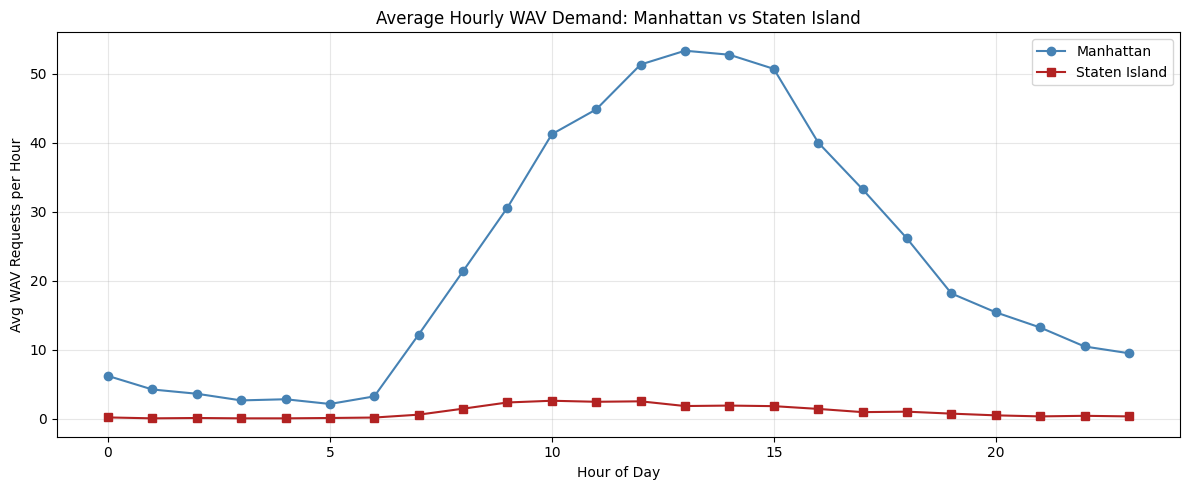

In [ ]:
# Average demand by hour of day — side by side comparison
fig, ax = plt.subplots(figsize=(12, 5))

m_hourly.groupby('hour_of_day')['total_demand'].mean().plot(
    ax=ax, label='Manhattan', color='steelblue', marker='o')
s_hourly.groupby('hour_of_day')['total_demand'].mean().plot(
    ax=ax, label='Staten Island', color='firebrick', marker='s')

ax.set_title('Average Hourly WAV Demand: Manhattan vs Staten Island')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg WAV Requests per Hour')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Key Findings

**Model Performance:**
SARIMAX(1,0,1)(1,0,1)[24] outperformed all baseline models for both boroughs:
- Manhattan RMSE: 8.20 vs Seasonal Naive baseline of 13.25 (38% improvement)
- Staten Island RMSE: 1.33 vs Seasonal Naive baseline of 1.53 (13% improvement)

**Seasonal Structure:**
The ar.S.L24 coefficient for Manhattan (0.996) is significantly higher than
Staten Island (0.630), indicating that Manhattan WAV demand has a much stronger
and more persistent 24-hour seasonal memory. Yesterday's demand at a given hour
is almost perfectly predictive of today's demand at the same hour in Manhattan,
whereas Staten Island demand is more volatile and less predictable.

**Exogenous Variables:**
- `is_peak_weekday` is statistically significant in both boroughs (p=0.015 Manhattan,
  p<0.001 Staten Island), confirming that weekday peak hours drive WAV demand.
- `is_peak_weekend` is only significant in Staten Island (p<0.001) but not Manhattan
  (p=0.190). This suggests that in Manhattan, subway and transit alternatives suppress
  WAV demand during weekend peak hours, while Staten Island residents — with fewer
  transit options — continue to rely on WAV services on weekends.
- `lagged_trip_time` is significant in both boroughs (p<0.001), confirming that
  congestion from the previous hour positively predicts current WAV demand.

**Answer to Research Question:**
Peak-hour congestion affects WAV demand differently between the two boroughs.
Manhattan exhibits a stronger, more structured 24-hour demand cycle driven primarily
by weekday peak hours, consistent with a population that substitutes to transit on
weekends. Staten Island shows a weaker seasonal structure but more consistent demand
across both weekday and weekend peak hours, consistent with a population that has
no viable transit alternative and relies on WAV services regardless of congestion.
This supports our hypothesis that transit availability moderates the relationship
between congestion and WAV demand.